In [1]:
# ==========================================
# 📘 Notebook: Análise de Métricas de Textos
# ==========================================

# ---
# 🔹 1. Importar bibliotecas
# ---
import pandas as pd
import numpy as np
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

# ---
# 🔹 2. Definir funções auxiliares (já existentes no seu projeto)
# ---
# As funções abaixo são apenas placeholders.
# No seu ambiente, substitua pelos nomes reais das suas funções.

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

/home/arthurscalercio/anaconda3/envs/qwen3-clone/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
# ---
# 🔹 3. Carregar arquivos Parquet
# ---
# Ajuste os nomes/paths conforme necessário
files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/acordaos_tcu.parquet.final",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/datastf_paraphrases_v2.parquet.final",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/iudicium_textum_paraphrases_v2.parquet.final",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/mlp_pt_BRCAD-5.parquet.final",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/mlp_pt_CJPG.parquet.final",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/data/legal_pt/tesemo_v2.parquet.final"
]

dfs = []
for file in files:
    df = pd.read_parquet(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["paraphrase"].apply(contar_caracteres)
    df["para_words"] = df["paraphrase"].apply(contar_palavras)
    df["para_sents"] = df["paraphrase"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [16]:
import os
print(os.getcwd())
combined_df.to_parquet("statistics.parquet", index=False)

/home/arthurscalercio/repo/legal-doc-simplification-data/src


In [12]:
# ---
# 🔹 6. Estatísticas descritivas globais
# ---
cols = [
    "orig_chars", "orig_words", "orig_sents",
    "para_chars", "para_words", "para_sents",
    "char_ratio"
]

global_stats = combined_df[cols].agg(["count", "sum", "mean", "std"]).T
print("📊 Estatísticas globais (contagem, soma, média e desvio padrão):")
display(global_stats)

# ---
# 🔹 7. Estatísticas por arquivo de origem
# ---
grouped_stats = (
    combined_df.groupby("source_file")[cols]
    .agg(["count", "sum", "mean", "std"])
    .round(2)
)

print("📂 Estatísticas por arquivo:")
display(grouped_stats)

📊 Estatísticas globais (contagem, soma, média e desvio padrão):


,count,sum,mean,std
orig_chars,966344.0,3.175563e+09,3286.162248,2967.289999
orig_words,966344.0,6.073246e+08,628.476590,566.572653
orig_sents,966344.0,2.921927e+07,30.236921,26.324148
para_chars,966344.0,1.003099e+09,1038.034845,638.473230
para_words,966344.0,1.975154e+08,204.394542,123.167806
para_sents,966344.0,1.480600e+07,15.321662,8.808127
char_ratio,966344.0,4.633064e+05,0.479442,0.252613


📂 Estatísticas por arquivo:


orig_chars                      \
                                                  count        sum     mean   
source_file                                                                   
acordaos_tcu.parquet.final                       150733  414874814  2752.38   
datastf_paraphrases_v2.parquet.final              99244  294661838  2969.06   
iudicium_textum_paraphrases_v2.parquet.final      31718   76020403  2396.76   
mlp_pt_BRCAD-5.parquet.final                     200257  902127632  4504.85   
mlp_pt_CJPG.parquet.final                        167921  527821562  3143.27   
tesemo_v2.parquet.final                          316471  960056922  3033.63   

                                                      orig_words             \
                                                  std      count        sum   
source_file                                                                   
acordaos_tcu.parquet.final                    2986.09     150733   78180788   
datastf_paraphrases_v2.parquet.final          2846.58      99244   54396968   
iudicium_textum_paraphrases_v2.parquet.final  2389.16      31718   14338943   
mlp_pt_BRCAD-5.parquet.final                  3142.66     200257  173753234   
mlp_pt_CJPG.parquet.final                     2847.75     167921  105287277   
tesemo_v2.parquet.final                       2777.04     316471  181367372   

                                                             orig_sents  \
                                                mean     std      count   
source_file                                                               
acordaos_tcu.parquet.final                    518.67  559.28     150733   
datastf_paraphrases_v2.parquet.final          548.11  529.57      99244   
iudicium_textum_paraphrases_v2.parquet.final  452.08  448.96      31718   
mlp_pt_BRCAD-5.parquet.final                  867.65  599.83     200257   
mlp_pt_CJPG.parquet.final                     627.00  562.57     167921   
tesemo_v2.parquet.final                       573.09  526.60     316471   

                                                        ... para_words  \
                                                   sum  ...       mean   
source_file                                             ...              
acordaos_tcu.parquet.final                     2551126  ...     178.69   
datastf_paraphrases_v2.parquet.final           3314347  ...     167.17   
iudicium_textum_paraphrases_v2.parquet.final    761119  ...     177.27   
mlp_pt_BRCAD-5.parquet.final                   7233533  ...     248.51   
mlp_pt_CJPG.parquet.final                      5019753  ...     214.28   
tesemo_v2.parquet.final                       10339389  ...     197.87   

                                                     para_sents           \
                                                 std      count      sum   
source_file                                                                
acordaos_tcu.parquet.final                    112.50     150733  1685767   
datastf_paraphrases_v2.parquet.final          122.63      99244  1370463   
iudicium_textum_paraphrases_v2.parquet.final   90.61      31718   387212   
mlp_pt_BRCAD-5.parquet.final                  108.64     200257  3562777   
mlp_pt_CJPG.parquet.final                     115.44     167921  2671991   
tesemo_v2.parquet.final                       134.41     316471  5127786   

                                                           char_ratio  \
                                               mean    std      count   
source_file                                                             
acordaos_tcu.parquet.final                    11.18   6.77     150733   
datastf_paraphrases_v2.parquet.final          13.81   9.98      99244   
iudicium_textum_paraphrases_v2.parquet.final  12.21   6.36      31718   
mlp_pt_BRCAD-5.parquet.final                  17.79   7.03     200257   
mlp_pt_CJPG.parquet.final                     15.91   6.95     167921   
tesemo_v2

In [13]:
# ---
# 🔹 8. (Opcional) Salvar resultados
# ---
global_stats.to_csv("stats_global.csv")
grouped_stats.to_csv("stats_por_arquivo.csv")

print("✅ Análise concluída com sucesso!")

✅ Análise concluída com sucesso!


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

# ---
# 🔹 2. Definir funções auxiliares (já existentes no seu projeto)
# ---
# As funções abaixo são apenas placeholders.
# No seu ambiente, substitua pelos nomes reais das suas funções.

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

test_df = pd.read_parquet("/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/test_random.parquet")

test_df["orig_chars"] = test_df["original_text"].apply(contar_caracteres)
test_df["orig_words"] = test_df["original_text"].apply(contar_palavras)
test_df["orig_sents"] = test_df["original_text"].apply(count_sentences)
# Paraphrase
test_df["para_chars"] = test_df["paraphrase"].apply(contar_caracteres)
test_df["para_words"] = test_df["paraphrase"].apply(contar_palavras)
test_df["para_sents"] = test_df["paraphrase"].apply(count_sentences)

print(test_df["orig_words"].mean())
print(test_df["para_words"].mean())


620.0473141942583
202.17525257577273


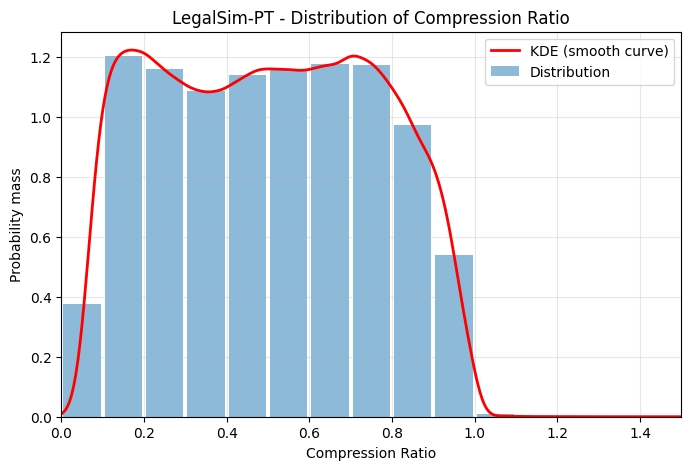

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ======================================
# 🔹 Plot da distribuição de char_ratio
# ======================================

# Remover possíveis NaN ou valores extremos
data = df["char_ratio"].dropna()
data = data[(data >= 0) & (data <= 1.5)]

# Criar bins de 0.1 em 0.1
bins = np.arange(0, 1.6, 0.1)

# Histograma normalizado (densidade)
counts, edges = np.histogram(data, bins=bins, density=True)
centers = 0.5 * (edges[1:] + edges[:-1])

# KDE (curva suave)
kde = gaussian_kde(data)
x_kde = np.linspace(0, 1.5, 300)
y_kde = kde(x_kde)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(centers, counts, width=0.09, alpha=0.5, label="Distribution")
plt.plot(x_kde, y_kde, color="red", linewidth=2, label="KDE (smooth curve)")

plt.title("LegalSim-PT - Distribution of Compression Ratio")
plt.xlabel("Compression Ratio")
plt.ylabel("Probability mass")
plt.xlim(0, 1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


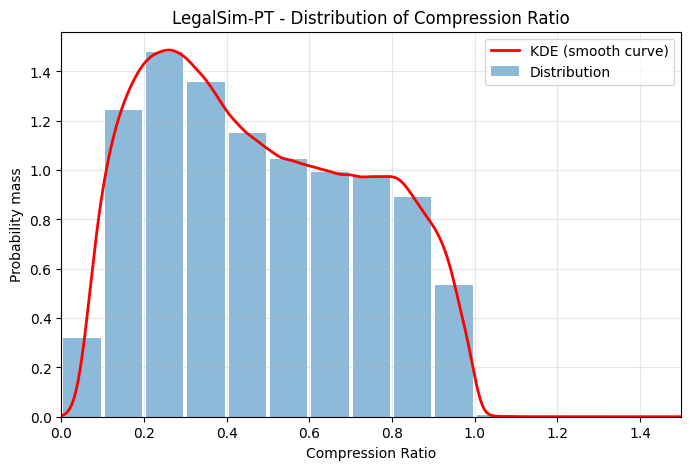

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ======================================
# 🔹 Plot da distribuição de char_ratio
# ======================================

# Remover possíveis NaN ou valores extremos
df=pd.read_parquet('statistics.parquet')
data = df["char_ratio"].dropna()
data = data[(data >= 0) & (data <= 1.5)]

# Criar bins de 0.1 em 0.1
bins = np.arange(0, 1.6, 0.1)

# Histograma normalizado (densidade)
counts, edges = np.histogram(data, bins=bins, density=True)
centers = 0.5 * (edges[1:] + edges[:-1])

# KDE (curva suave)
kde = gaussian_kde(data)
x_kde = np.linspace(0, 1.5, 300)
y_kde = kde(x_kde)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(centers, counts, width=0.09, alpha=0.5, label="Distribution")
plt.plot(x_kde, y_kde, color="red", linewidth=2, label="KDE (smooth curve)")

plt.title("LegalSim-PT - Distribution of Compression Ratio")
plt.xlabel("Compression Ratio")
plt.ylabel("Probability mass")
plt.xlim(0, 1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

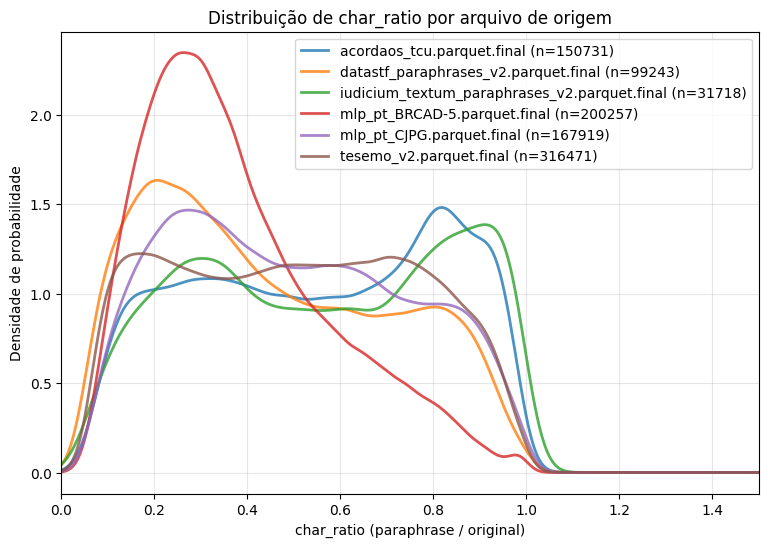

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ==========================================
# 🔹 Distribuições de char_ratio por arquivo
# ==========================================

# Filtrar valores válidos
df_plot = combined_df.dropna(subset=["char_ratio"])
df_plot = df_plot[(df_plot["char_ratio"] >= 0) & (df_plot["char_ratio"] <= 1.5)]

# Lista de arquivos
files = df_plot["source_file"].unique()
x_kde = np.linspace(0, 1.5, 300)

plt.figure(figsize=(9, 6))

# Plot sobreposto
for f in files:
    subset = df_plot[df_plot["source_file"] == f]["char_ratio"]
    if len(subset) > 1:  # evita erro no KDE
        kde = gaussian_kde(subset)
        y_kde = kde(x_kde)
        plt.plot(x_kde, y_kde, linewidth=2, label=f"{f} (n={len(subset)})", alpha=0.8)

plt.title("Distribuição de char_ratio por arquivo de origem")
plt.xlabel("char_ratio (paraphrase / original)")
plt.ylabel("Densidade de probabilidade")
plt.xlim(0, 1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


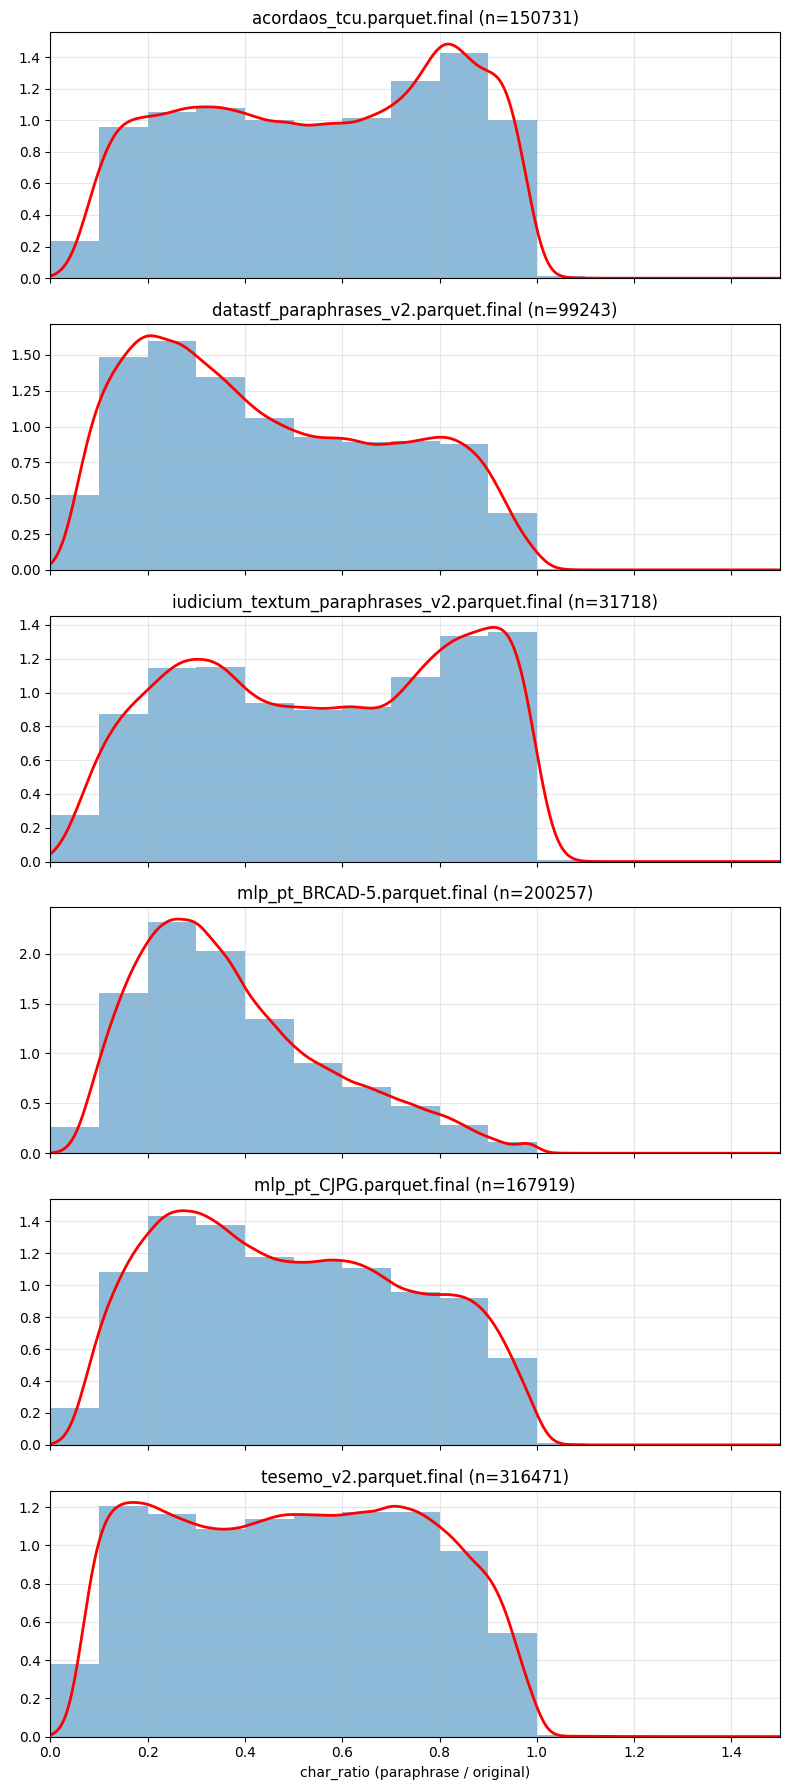

In [20]:
fig, axes = plt.subplots(nrows=len(files), ncols=1, figsize=(8, 3*len(files)), sharex=True)

for ax, f in zip(axes, files):
    subset = df_plot[df_plot["source_file"] == f]["char_ratio"]
    kde = gaussian_kde(subset)
    y_kde = kde(x_kde)
    ax.hist(subset, bins=np.arange(0, 1.6, 0.1), density=True, alpha=0.5)
    ax.plot(x_kde, y_kde, color="red", linewidth=2)
    ax.set_title(f"{f} (n={len(subset)})")
    ax.set_xlim(0, 1.5)
    ax.grid(alpha=0.3)

plt.xlabel("char_ratio (paraphrase / original)")
plt.tight_layout()
plt.show()

In [2]:
# ---
# 🔹 3. Carregar arquivos csv
# ---
# Ajuste os nomes/paths conforme necessário
files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/val_challenge_good.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/val_challenge_hard.csv"
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["paraphrase"].apply(contar_caracteres)
    df["para_words"] = df["paraphrase"].apply(contar_palavras)
    df["para_sents"] = df["paraphrase"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [7]:
print(combined_df['original_text'][399])
combined_df.to_csv("challenge_sets" + ".csv", index=False)

RECURSO ESPECIAL Nº 0974180 - DF (6078/8678071-4)
DECISÃO
Trata-se de recurso especial interposto em face de acórdão assim
ementado:
“APELAÇÃO CÍVEL. DIREITO CIVIL. DIREITO PROCESSUAL CIVIL. AÇÃO DE
COBRANÇA. COERDEIRO. USUFRUTO. IMÓVEIS. ALUGUÉIS. PRESCRIÇÃO.
RECONHECIDO. RECURSO CONHECIDO E NÃO PROVIDO.
1. Segundo o princípio da actio nata, o prazo prescricional somente se inicia
quando a pretensão pode ser exercida, sendo desarrazoado que o titular de um
direito subjetivo violado tenha contra si o início do prazo prescricional quando não
há qualquer possibilidade de exercitar sua pretensão, não havendo comportamento
negligente ou desidioso de sua parte.
2. No caso em análise, discute-se o direito do autor ao recebimento de aluguéis em
razão de suposta ocupação exclusiva de imóveis do espólio do genitor. O exercício
da pretensão nasceu com o início da ocupação irregular, ou seja, com o
falecimento do de cujus, transcorridos três anos e não exercido o direito de ação,
necessário o rec

In [1]:
import pandas as pd
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_good_bode_results_v2.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_hard_bode_results_v2.csv",
    
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["bode_output"].apply(contar_caracteres)
    df["para_words"] = df["bode_output"].apply(contar_palavras)
    df["para_sents"] = df["bode_output"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

/home/arthurscalercio/anaconda3/envs/qwen3-clone/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
print(combined_df['bode_output'][399])
combined_df.to_csv("challenge_sets_bode" + ".csv", index=False)

ese de que a prescrição tenha sido
interrompida, se o prazo prescricional iniciou-se com o trânsito em julgado da ação
de inventário ou com a manifestação do autor no processo de inventário.
3- A tese do apelante é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
4- A tese do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
5- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
6- A decisão do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
7- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
8- A decisão do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
9- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inv

In [3]:
files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_good_qwen2_5_results_batched.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_hard_qwen2_5_results_batched_new_p2.csv",
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["qwen2.5_output"].apply(contar_caracteres)
    df["para_words"] = df["qwen2.5_output"].apply(contar_palavras)
    df["para_sents"] = df["qwen2.5_output"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [4]:
print(combined_df['qwen2.5_output'][399])
combined_df.to_csv("challenge_sets_qwen2.5" + ".csv", index=False)

Trata-se de recurso especial interposto contra acórdão que reconheceu a prescrição em uma ação de cobrança de aluguéis. A decisão de origem foi mantida, mas o recurso especial foi parcialmente provido para determinar que os aluguéis devem ser pagos após a efetiva oposição dos demais herdeiros, após o trânsito em julgado da ação de inventário. Os autos foram remetidos ao Tribunal de origem para regular processamento da ação de arbitramento de aluguéis.
